# Scenario B1: Multiple Suppliers — No REC (Net Generators)

**Description:** Two independent suppliers, no REC. Each balancing group
contains a single member type (consumers-only or net-generators-only),
isolating the financial dynamics of pure demand vs pure generation portfolios.
Prosumers are modelled as **net generators** (RES only, no local load).

**Participant–supplier assignment (homogeneous BGs):**
| Supplier / BG | Participants | Type |
|---|---|---|
| SUP_A / BG_A | consumer_001–006 (6 members) | Consumers only |
| SUP_B / BG_B | prosumer_001–003 (3 members) | Net generators only |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (6 consumers), BG_B (3 net generators) |
| RECs | None |
| Prosumer type | **Net generator** (RES only, no local load) |
| Battery | None |

**Research role:** Tests whether supplier fragmentation alone (without a REC)
changes imbalance costs and supplier revenue, compared to the single-supplier
baseline A1.

**Comparison pairs (net-generator track):**
- B1 vs A1 → effect of multi-supplier competition (no REC)
- B1 vs B2 → incremental value of adding a cross-supplier REC
- B1 vs B2-forecasts → REC value under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "B1_multiple_suppliers_without_rec(net generators).json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B1_net_generators")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - (Skipped for B1 - no REC configured)
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B1_net_generators
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B1_net_generators
  System  : Multiple Suppliers without REC - Scenario B1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (70272, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 26)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [7]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B1_NET_GENERATORS

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €        0.00
      Balancing Rewards   : €       18.51
      Retail Sales        : €   29,814.30
      ────────────────────────────────────────────
      Total Revenue       : €   29,832.81

    COSTS:
      Market Purchases    : €    4,749.35
      Balancing Penalties  : €       18.87
      Retail Purchases     : €        0.00
      ────────────────────────────────────────────
      Total Costs          : €    4,768.22

    PROFIT/LOSS:
      Annual Total         : €   25,064.59
      Monthly Average      : €    2,088.72

    IMBALANCE:
      System Position      : SHORT
      Total Imbalance      :         0.00 MWh
      BG Actual Position   :       148.33 MWh
      BG Forecast Position :       148.33 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €    1,568.91
      Balancing Rewards   : €       60.70
      Retail Sales        : €        0.00
    

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

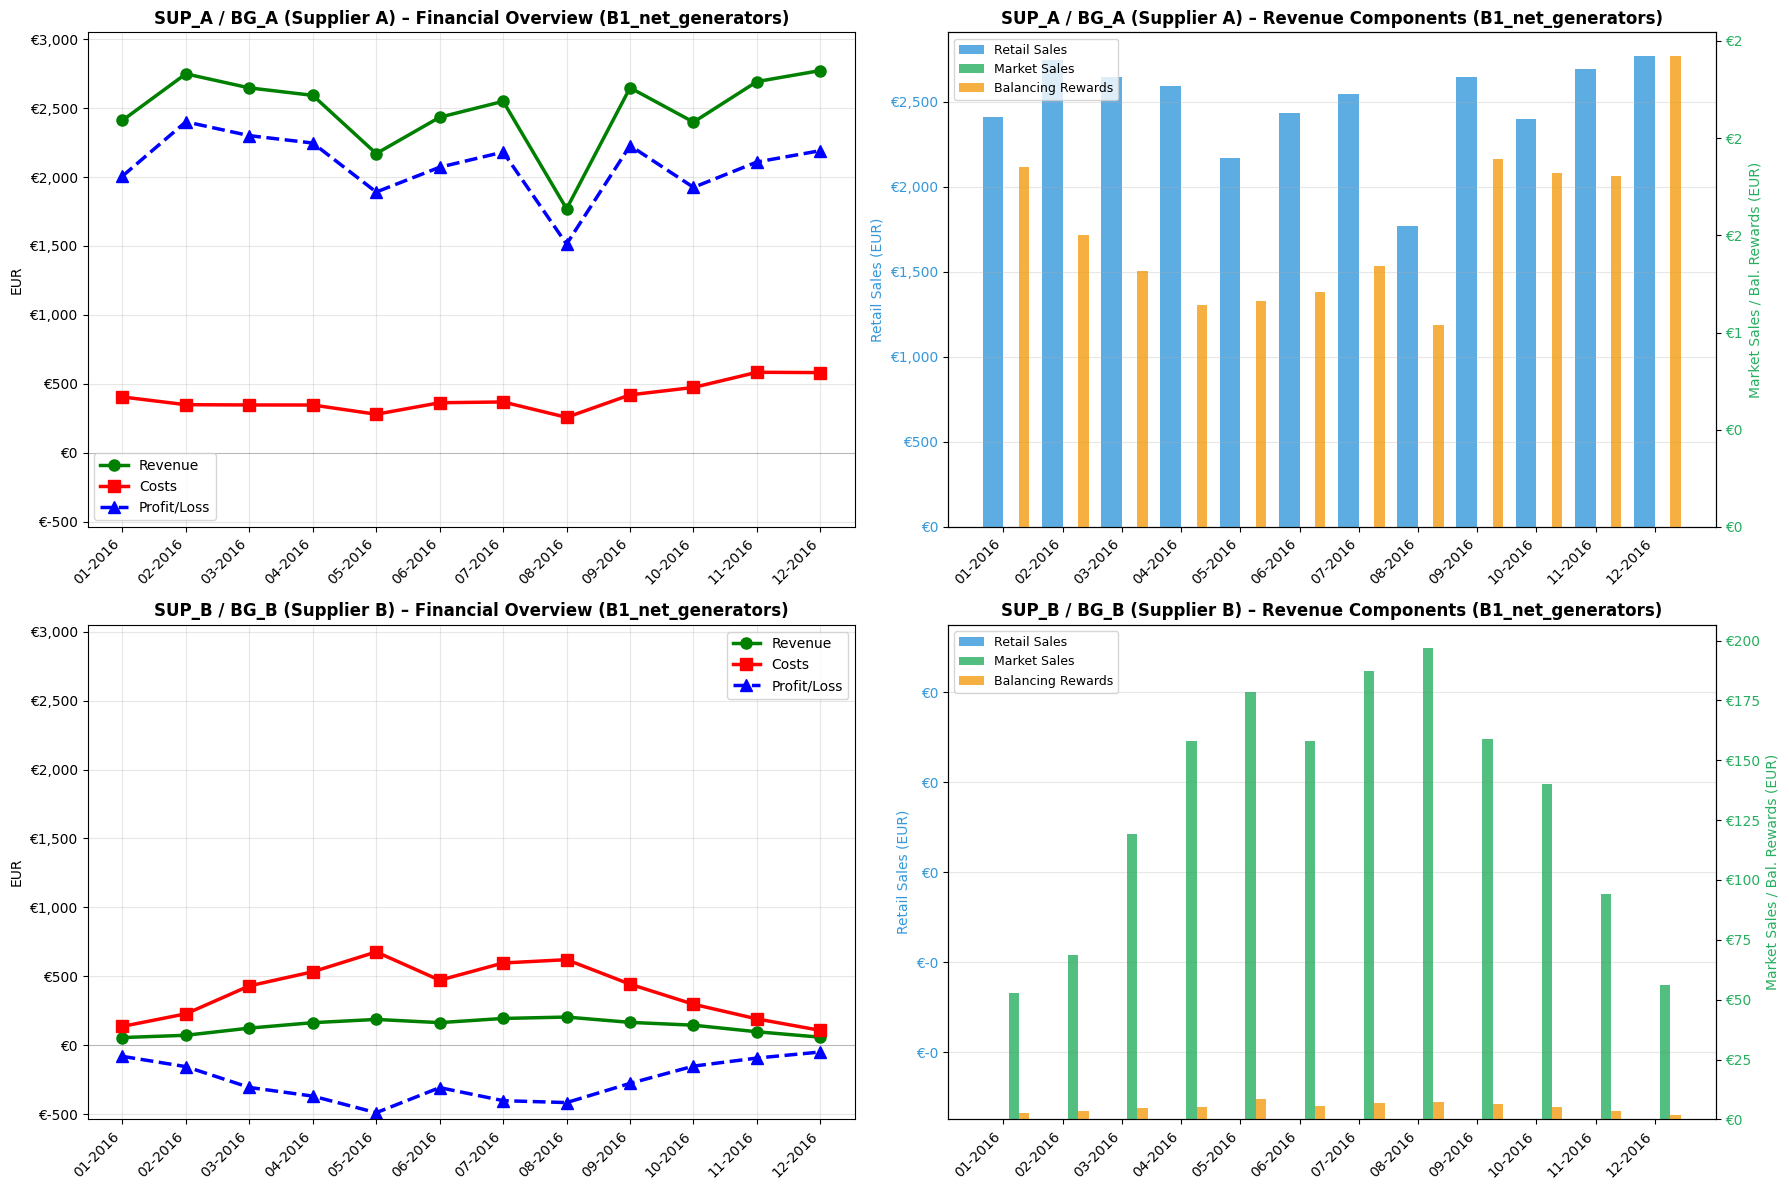

In [8]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

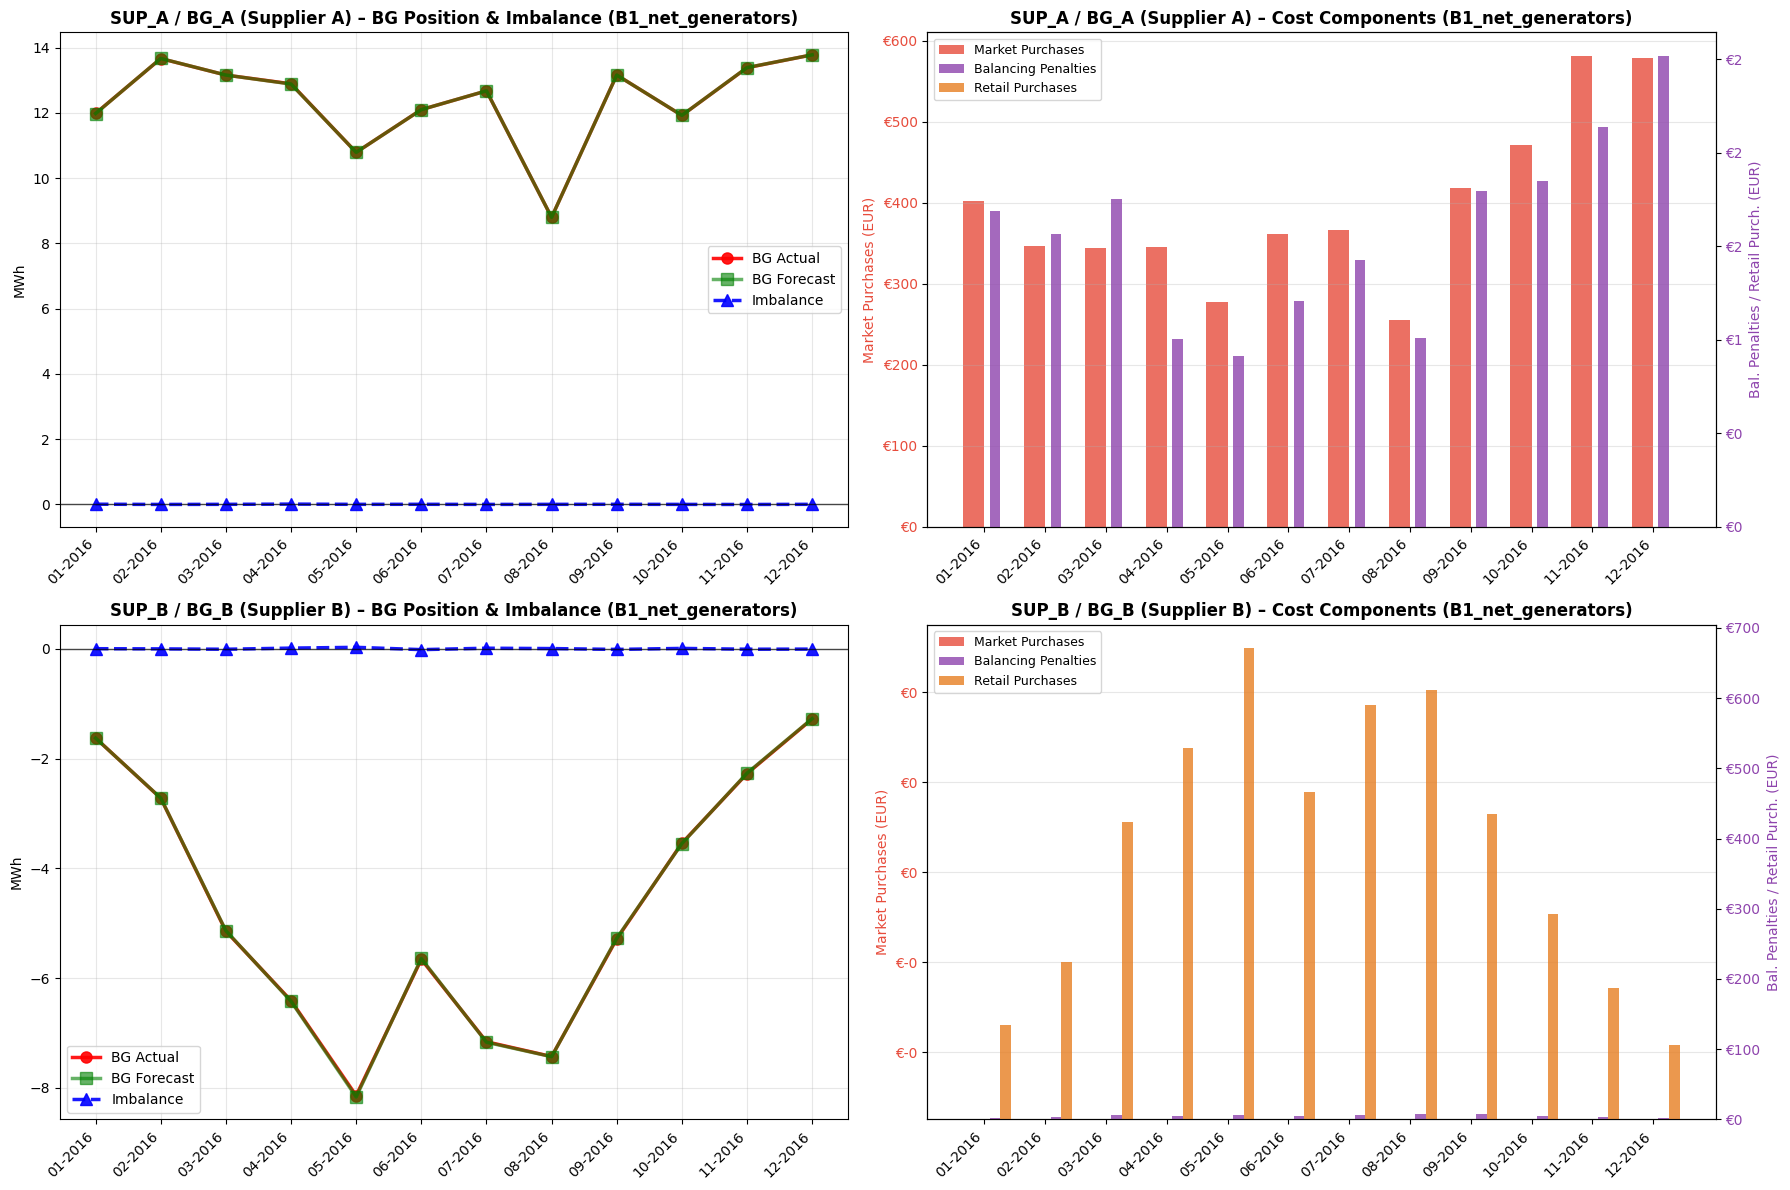

In [9]:
pipe.plot_imbalances()

## 7. Supplier Comparison
Compare financial performance across the two suppliers (SUP_A, SUP_B).

In [12]:
pipe.es_monthly_analysis_df.groupby('supplier_id').agg({
    'total_revenue_eur': 'sum',
    'total_costs_eur': 'sum',
    'profit_loss_eur': 'sum',
    'imbalance_mwh': 'sum'
})

,total_revenue_eur,total_costs_eur,profit_loss_eur,imbalance_mwh
supplier_id,,,,
SUP_A,29832.811800,4768.219594,25064.592206,0.003539
SUP_B,1629.603491,4729.839889,-3100.236398,0.003940


In [4]:
df = pipe.es_monthly_analysis_df
sa = df[df['supplier_id'] == 'SUP_A']
print("=== SUP_A / BG_A ===")
print(f"BG Actual: {sa['balancing_group_actual_mwh'].sum():.4f} MWh")
print(f"BG Forecast: {sa['balancing_group_forecast_mwh'].sum():.4f} MWh")
print(f"Imbalance: {sa['imbalance_mwh'].sum():.4f} MWh")
print(f"Imbalance Reward: {sa['imbalance_reward'].sum():.2f}")
print(f"Imbalance Penalty: {sa['imbalance_penalty'].sum():.2f}")
print(f"Revenue - Market Sales: {sa['revenue_energy_market_sales_eur'].sum():.2f}")
print(f"Revenue - Bal Rewards: {sa['revenue_balancing_rewards_eur'].sum():.2f}")
print(f"Revenue - Retail Sales: {sa['revenue_retail_sales_eur'].sum():.2f}")
print(f"Total Revenue: {sa['total_revenue_eur'].sum():.2f}")
print(f"Cost - Market Purchases: {sa['cost_energy_market_purchases_eur'].sum():.2f}")
print(f"Cost - Bal Penalties: {sa['cost_balancing_penalties_eur'].sum():.2f}")
print(f"Cost - Retail Purchases (FI): {sa['cost_retail_purchases_eur'].sum():.2f}")
print(f"Total Costs: {sa['total_costs_eur'].sum():.2f}")
print(f"Profit: {sa['profit_loss_eur'].sum():.2f}")
print(f"Monthly avg profit: {sa['profit_loss_eur'].mean():.2f}")
print(f"Monthly min profit: {sa['profit_loss_eur'].min():.2f}")
print(f"Monthly max profit: {sa['profit_loss_eur'].max():.2f}")
print(f"\nActual Load: {sa['actual_load_mwh'].sum():.2f} MWh")
print(f"Actual Gen: {sa['actual_gen_mwh'].sum():.2f} MWh")

=== SUP_A / BG_A ===
BG Actual: 148.3299 MWh
BG Forecast: 148.3263 MWh
Imbalance: 0.0035 MWh
Imbalance Reward: 18.51
Imbalance Penalty: 18.87
Revenue - Market Sales: 0.00
Revenue - Bal Rewards: 18.51
Revenue - Retail Sales: 29814.30
Total Revenue: 29832.81
Cost - Market Purchases: 4749.35
Cost - Bal Penalties: 18.87
Cost - Retail Purchases (FI): 0.00
Total Costs: 4768.22
Profit: 25064.59
Monthly avg profit: 2088.72
Monthly min profit: 1513.39
Monthly max profit: 2400.50

Actual Load: 148.33 MWh
Actual Gen: 0.00 MWh


In [5]:
sb = df[df['supplier_id'] == 'SUP_B']
print("=== SUP_B / BG_B ===")
print(f"BG Actual: {sb['balancing_group_actual_mwh'].sum():.4f} MWh")
print(f"BG Forecast: {sb['balancing_group_forecast_mwh'].sum():.4f} MWh")
print(f"Imbalance: {sb['imbalance_mwh'].sum():.4f} MWh")
print(f"Imbalance Reward: {sb['imbalance_reward'].sum():.2f}")
print(f"Imbalance Penalty: {sb['imbalance_penalty'].sum():.2f}")
print(f"Revenue - Market Sales: {sb['revenue_energy_market_sales_eur'].sum():.2f}")
print(f"Revenue - Bal Rewards: {sb['revenue_balancing_rewards_eur'].sum():.2f}")
print(f"Revenue - Retail Sales: {sb['revenue_retail_sales_eur'].sum():.2f}")
print(f"Total Revenue: {sb['total_revenue_eur'].sum():.2f}")
print(f"Cost - Market Purchases: {sb['cost_energy_market_purchases_eur'].sum():.2f}")
print(f"Cost - Bal Penalties: {sb['cost_balancing_penalties_eur'].sum():.2f}")
print(f"Cost - Retail Purchases (FI): {sb['cost_retail_purchases_eur'].sum():.2f}")
print(f"Total Costs: {sb['total_costs_eur'].sum():.2f}")
print(f"Profit: {sb['profit_loss_eur'].sum():.2f}")
print(f"Monthly avg profit: {sb['profit_loss_eur'].mean():.2f}")
print(f"Monthly min profit: {sb['profit_loss_eur'].min():.2f}")
print(f"Monthly max profit: {sb['profit_loss_eur'].max():.2f}")
print(f"\nActual Load: {sb['actual_load_mwh'].sum():.2f} MWh")
print(f"Actual Gen: {sb['actual_gen_mwh'].sum():.2f} MWh")

=== SUP_B / BG_B ===
BG Actual: -56.6757 MWh
BG Forecast: -56.6797 MWh
Imbalance: 0.0039 MWh
Imbalance Reward: 60.70
Imbalance Penalty: 59.76
Revenue - Market Sales: 1568.91
Revenue - Bal Rewards: 60.70
Revenue - Retail Sales: 0.00
Total Revenue: 1629.60
Cost - Market Purchases: 0.00
Cost - Bal Penalties: 59.76
Cost - Retail Purchases (FI): 4670.08
Total Costs: 4729.84
Profit: -3100.24
Monthly avg profit: -258.35
Monthly min profit: -489.79
Monthly max profit: -49.35

Actual Load: 0.00 MWh
Actual Gen: 56.68 MWh


In [7]:
# Monthly BG positions
print("=== Monthly BG Actual Positions ===")
for _, row in df.sort_values(['supplier_id','datetime']).iterrows():
    print(f"{row['supplier_id']} {row['datetime']}: BG={row['balancing_group_actual_mwh']:.4f}, Fcast={row['balancing_group_forecast_mwh']:.4f}, Imb={row['imbalance_mwh']:.4f}")

=== Monthly BG Actual Positions ===
SUP_A 01-2016: BG=11.9856, Fcast=11.9817, Imb=0.0039
SUP_A 02-2016: BG=13.6674, Fcast=13.6704, Imb=-0.0030
SUP_A 03-2016: BG=13.1612, Fcast=13.1610, Imb=0.0002
SUP_A 04-2016: BG=12.8928, Fcast=12.8857, Imb=0.0071
SUP_A 05-2016: BG=10.7909, Fcast=10.7909, Imb=0.0000
SUP_A 06-2016: BG=12.1018, Fcast=12.1006, Imb=0.0012
SUP_A 07-2016: BG=12.6758, Fcast=12.6778, Imb=-0.0020
SUP_A 08-2016: BG=8.7990, Fcast=8.7992, Imb=-0.0002
SUP_A 09-2016: BG=13.1629, Fcast=13.1616, Imb=0.0013
SUP_A 10-2016: BG=11.9241, Fcast=11.9255, Imb=-0.0014
SUP_A 11-2016: BG=13.3867, Fcast=13.3908, Imb=-0.0042
SUP_A 12-2016: BG=13.7818, Fcast=13.7811, Imb=0.0006
SUP_B 01-2016: BG=-1.6271, Fcast=-1.6281, Imb=0.0011
SUP_B 02-2016: BG=-2.7226, Fcast=-2.7203, Imb=-0.0023
SUP_B 03-2016: BG=-5.1450, Fcast=-5.1360, Imb=-0.0090
SUP_B 04-2016: BG=-6.4108, Fcast=-6.4225, Imb=0.0117
SUP_B 05-2016: BG=-8.1397, Fcast=-8.1658, Imb=0.0261
SUP_B 06-2016: BG=-5.6589, Fcast=-5.6429, Imb=-0.0160
SUP_

In [9]:
# Monthly SUP_B Costs
print("=== Monthly SUP_B Costs ===")
for _, row in sb.sort_values('datetime').iterrows():
    print(f"{row['datetime']}: MP={row['cost_energy_market_purchases_eur']:.2f}, BP={row['cost_balancing_penalties_eur']:.2f}, FI={row['cost_retail_purchases_eur']:.2f}, Total={row['total_costs_eur']:.2f}")

=== Monthly SUP_B Costs ===
01-2016: MP=0.00, BP=2.31, FI=134.07, Total=136.38
02-2016: MP=0.00, BP=3.24, FI=224.34, Total=227.59
03-2016: MP=0.00, BP=6.46, FI=423.94, Total=430.41
04-2016: MP=0.00, BP=4.50, FI=528.25, Total=532.75
05-2016: MP=0.00, BP=6.04, FI=670.71, Total=676.75
06-2016: MP=0.00, BP=5.20, FI=466.29, Total=471.49
07-2016: MP=0.00, BP=6.54, FI=589.93, Total=596.47
08-2016: MP=0.00, BP=8.37, FI=612.14, Total=620.51
09-2016: MP=0.00, BP=7.06, FI=435.58, Total=442.63
10-2016: MP=0.00, BP=4.92, FI=291.96, Total=296.88
11-2016: MP=0.00, BP=3.19, FI=187.48, Total=190.67
12-2016: MP=0.00, BP=1.92, FI=105.38, Total=107.30


In [10]:
# Monthly SUP_B Revenue + P/L
print("=== Monthly SUP_B Revenue ===")
for _, row in sb.sort_values('datetime').iterrows():
    print(f"{row['datetime']}: MS={row['revenue_energy_market_sales_eur']:.2f}, BR={row['revenue_balancing_rewards_eur']:.2f}, RS={row['revenue_retail_sales_eur']:.2f}, Total={row['total_revenue_eur']:.2f}, P/L={row['profit_loss_eur']:.2f}")

=== Monthly SUP_B Revenue ===
01-2016: MS=52.72, BR=2.69, RS=0.00, Total=55.41, P/L=-80.97
02-2016: MS=68.59, BR=3.41, RS=0.00, Total=72.00, P/L=-155.59
03-2016: MS=119.31, BR=4.64, RS=0.00, Total=123.95, P/L=-306.46
04-2016: MS=158.20, BR=5.14, RS=0.00, Total=163.34, P/L=-369.41
05-2016: MS=178.53, BR=8.43, RS=0.00, Total=186.96, P/L=-489.79
06-2016: MS=158.06, BR=5.61, RS=0.00, Total=163.67, P/L=-307.82
07-2016: MS=187.40, BR=6.67, RS=0.00, Total=194.08, P/L=-402.40
08-2016: MS=196.72, BR=7.44, RS=0.00, Total=204.15, P/L=-416.36
09-2016: MS=159.07, BR=6.53, RS=0.00, Total=165.60, P/L=-277.03
10-2016: MS=140.08, BR=5.01, RS=0.00, Total=145.09, P/L=-151.79
11-2016: MS=94.06, BR=3.33, RS=0.00, Total=97.39, P/L=-93.28
12-2016: MS=56.18, BR=1.78, RS=0.00, Total=57.95, P/L=-49.35


In [11]:
# Monthly SUP_A costs and revenue
print("=== Monthly SUP_A Costs ===")
for _, row in sa.sort_values('datetime').iterrows():
    print(f"{row['datetime']}: MP={row['cost_energy_market_purchases_eur']:.2f}, BP={row['cost_balancing_penalties_eur']:.2f}, FI={row['cost_retail_purchases_eur']:.2f}, Total={row['total_costs_eur']:.2f}")
print("\n=== Monthly SUP_A Revenue ===")
for _, row in sa.sort_values('datetime').iterrows():
    print(f"{row['datetime']}: MS={row['revenue_energy_market_sales_eur']:.2f}, BR={row['revenue_balancing_rewards_eur']:.2f}, RS={row['revenue_retail_sales_eur']:.2f}, Total={row['total_revenue_eur']:.2f}, P/L={row['profit_loss_eur']:.2f}")

# Combined totals
print(f"\n=== Combined ===")
print(f"Combined Revenue: {df['total_revenue_eur'].sum():.2f}")
print(f"Combined Costs: {df['total_costs_eur'].sum():.2f}")
print(f"Combined Profit: {df['profit_loss_eur'].sum():.2f}")
# Config structure
cfg = pipe.config
consumers = cfg.get('consumers', [])
prosumers = cfg.get('prosumers', [])
supa_c = [c for c in consumers if c['supplier']['supplier_id'] == 'SUP_A']
supb_c = [c for c in consumers if c['supplier']['supplier_id'] == 'SUP_B']
supa_p = [p for p in prosumers if p['supplier']['supplier_id'] == 'SUP_A']
supb_p = [p for p in prosumers if p['supplier']['supplier_id'] == 'SUP_B']
print(f"SUP_A: {len(supa_c)} consumers, {len(supa_p)} prosumers")
print(f"SUP_B: {len(supb_c)} consumers, {len(supb_p)} prosumers")

=== Monthly SUP_A Costs ===
01-2016: MP=402.72, BP=1.69, FI=0.00, Total=404.41
02-2016: MP=346.58, BP=1.57, FI=0.00, Total=348.15
03-2016: MP=344.63, BP=1.75, FI=0.00, Total=346.39
04-2016: MP=344.97, BP=1.00, FI=0.00, Total=345.97
05-2016: MP=278.02, BP=0.92, FI=0.00, Total=278.94
06-2016: MP=361.23, BP=1.21, FI=0.00, Total=362.44
07-2016: MP=366.70, BP=1.43, FI=0.00, Total=368.12
08-2016: MP=255.23, BP=1.01, FI=0.00, Total=256.24
09-2016: MP=417.75, BP=1.79, FI=0.00, Total=419.54
10-2016: MP=471.61, BP=1.85, FI=0.00, Total=473.46
11-2016: MP=581.22, BP=2.14, FI=0.00, Total=583.36
12-2016: MP=578.69, BP=2.52, FI=0.00, Total=581.20

=== Monthly SUP_A Revenue ===
01-2016: MS=0.00, BR=1.85, RS=2409.10, Total=2410.95, P/L=2006.54
02-2016: MS=0.00, BR=1.50, RS=2747.15, Total=2748.65, P/L=2400.50
03-2016: MS=0.00, BR=1.32, RS=2645.39, Total=2646.71, P/L=2300.33
04-2016: MS=0.00, BR=1.14, RS=2591.45, Total=2592.60, P/L=2246.63
05-2016: MS=0.00, BR=1.16, RS=2168.97, Total=2170.14, P/L=1891.20